In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fenics import Function, plot
from utils.problem_setup import TestProblemsSetup
from utils.utils import disk_cache

from utils.colors import CMAP
from utils.plotting import save_plot
import matplotlib.patches as patches

#from algorithms.dynamical_low_rank_solver import DynamicalLowRankSolver
from algorithms.cg_solvers import DynamicalLowRankCG, DynamicalLowRankApproximation, DynamicalLowRankPCG
from algorithms.rsvd_solvers import MatrixFreeRSVD

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})


SETUP = TestProblemsSetup(n=64)
PROBLEM_PARAMS = SETUP.problem_params
PROBLEMS = SETUP.get_test_problems()
SEED = 15

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def as_func(x, V_h):
    f = Function(V_h)
    f.vector()[:] = x
    return f

def plot_multiple_f(solutions, pid, params=None, names=None, fig_name=None, shrink=0.3):
    pb = PROBLEMS[pid]
    PARAMS = PROBLEM_PARAMS[pid]
    f_list = [as_func(x, pb['V_h']) for x in solutions]

    width, height = PARAMS['width'], PARAMS['height']
    x0s, y0s = PARAMS['x0'], PARAMS['y0']

    fig, axes = plt.subplots(1, len(f_list), figsize=(9, 6.06), constrained_layout=True)

    if names is None:
        names = ['' for _ in axes.flat]

    for ax, func, name in zip(axes.flat, f_list, names):
        plt.sca(ax)
        #vmin = np.min(func.vector().get_local())

        p = plot(func, title=name, cmap=CMAP)
        #fig.colorbar(p, ax=ax, format="%.2f", shrink=shrink)
        ax.set_xticks([])
        ax.set_yticks([])

        for x0, y0 in zip(x0s, y0s):
            square = patches.Rectangle(
                (x0, y0), width, height,
                edgecolor="white",
                facecolor="none"
            )
            ax.add_patch(square)

    save_plot(fig_name=fig_name)
    plt.show()

---
### **Different methods and different restart periods**


In [3]:
SOLVERS = {
    'DLRA': DynamicalLowRankApproximation,
    'DLRA-CG': DynamicalLowRankCG
}

@disk_cache('../../results/rate_of_convergence')
def experiment1(param_grid, max_iter, max_rank, lam, k, pid):
    pb = PROBLEMS[pid]
    rsvd = MatrixFreeRSVD(pb['V_h']); rsvd.solve(k=k)
    w = rsvd.weights()

    errors, solutions, residuals = [], [], []

    for params in param_grid:
        solver = SOLVERS[params['solver']](rsvd, pb['x'])
        args = params['args']
        x = solver.solve(
            pb['y'], w, lam,
            seed=SEED, max_iter=max_iter, max_rank=max_rank, rtol=0, **args
        )
        
        errors.append(solver.error.copy())
        residuals.append(solver.residual.copy())
        solutions.append(x)

    return {'solutions': solutions, 'errors': errors, 'residuals': residuals}

In [4]:
param_grid = [
    {'solver': 'DLRA', 'name': 'adam',          'args': {'method': 'adam'}},
    {'solver': 'DLRA', 'name': 'fixed',         'args': {'method': 'fixed', 'alpha': 2000}},
    {'solver': 'DLRA', 'name': 'steepest',      'args': {'method': 'sd'}},
    {'solver': 'DLRA-CG', 'name': 'DLRA-CG',    'args': {'restart_every': None}},
    {'solver': 'DLRA-CG', 'name': 'rs-DLRA-CG', 'args': {'restart_every': 10}}
]

result1 = experiment1(param_grid, max_iter=25_000, max_rank=1, lam=1e-4, k=50, pid='I')


In [9]:
param_grid2 = [
    {'solver': 'DLRA-CG', 'args': {'restart_every': 5}},
    {'solver': 'DLRA-CG', 'args': {'restart_every': 25}},
    {'solver': 'DLRA-CG', 'args': {'restart_every': 100}},
    {'solver': 'DLRA-CG', 'args': {'restart_every': None}},
]

result2 = experiment1(param_grid2, max_iter=25_000, max_rank=1, lam=1e-4, k=50, pid='I')
Nr_list = [p['args']['restart_every'] for p in param_grid2]

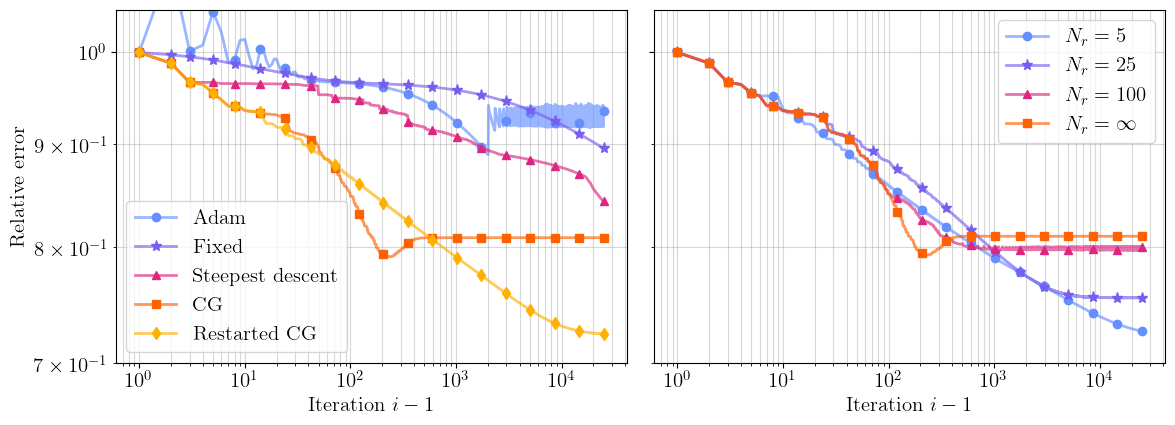

In [15]:
def plot_errors(e_list, names=None, fig_name=None, n_marks=20, ax=None, ylim=None, ylabel=True):
    from utils.colors import C5, M, MS
    from utils.plotting import save_plot
    from matplotlib.lines import Line2D

    if ax is None: fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    else: fig = ax.figure
    if names is None: names = ['' for _ in e_list]

    for i, e in enumerate(e_list):
        x = np.arange(1, len(e) + 1)

        x_marks = np.logspace(np.log10(x[0]), np.log10(x[-1]), n_marks)
        mark_idx = np.unique([np.abs(x - xm).argmin() for xm in x_marks])

        ax.loglog(x, e, lw=2.0, label=names[i], markevery=mark_idx, c=C5[i], alpha=.65)
        ax.loglog(x, e, M[i], lw=2.0, markevery=mark_idx, ms=MS[i], c=C5[i])

    if ylim is not None: ax.set_ylim(ylim)

    handles, labels = [], names
    for i in range(len(e_list)):
        legend_line = Line2D([0], [0], color=C5[i], linewidth=2.0, alpha=.65)
        legend_marker = Line2D([0], [0], color=C5[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))

    if ylabel: ax.set_ylabel('Relative error')
    ax.set_xlabel('Iteration $i - 1$')
    ax.grid(True, which='both', alpha=.5)
    ax.legend(handles=handles, labels=labels)

    if fig_name is not None:
        save_plot(fig_name)

names  = ['Adam', 'Fixed', 'Steepest descent', 'CG', 'Restarted CG']
names2 = [f'$N_r = {N_r}$' for N_r in Nr_list[:3]] + ['$N_r = \infty$']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

plot_errors(result1['errors'], names=names, ax=axes[0], ylim=(0.7, 1.05))
plot_errors(result2['errors'], names=names2, ax=axes[1], ylabel=False)

plt.tight_layout()
save_plot('number_of_iterations')
plt.show()

In [20]:
etols = [0.90, 0.85, 0.80, 0.75]
names = ['Adam', 'Fixed', 'Steepest descent', 'DLRA-CG', 'Restarted DLRA-CG']

for name, e in zip(names, result1['errors']):
    e_arr = np.array(e)
    vals = []
    for tol in etols:
        hits = np.where(e_arr < tol)[0]
        vals.append(str(int(hits[0]) + 1) if len(hits) > 0 else r'\texttt{--}')
    print(f"{name:<22} & {' & '.join(vals)} \\\\")


Adam                   & 1657 & \texttt{--} & \texttt{--} & \texttt{--} \\
Fixed                  & 21532 & \texttt{--} & \texttt{--} & \texttt{--} \\
Steepest descent       & 1534 & 21778 & \texttt{--} & \texttt{--} \\
DLRA-CG                & 49 & 100 & 176 & \texttt{--} \\
Restarted DLRA-CG      & 36 & 160 & 736 & 3976 \\


---
### **Different conditions numbers (k, $\lambda$)**

In [47]:
@disk_cache('../../results/rate_of_convergence')
def experiment2(k_list, lam, max_iter, max_rank, pid):
    pb = PROBLEMS[pid]
    errors, solutions, residuals = [], [], []
    kappas = []  # Condition numbers!


    for k in k_list:
        rsvd = MatrixFreeRSVD(pb['V_h'])
        _, S, _ = rsvd.solve(k=k)
        kappa = S[0] / S[-1]
        w = rsvd.weights()

        solver = DynamicalLowRankCG(rsvd, pb['x'])
        x = solver.solve(
            pb['y'], w, lam,
            seed=SEED, max_iter=max_iter, max_rank=max_rank, rtol=0,
        )
        
        errors.append(solver.error.copy())
        residuals.append(solver.residual.copy())
        solutions.append(x)
        kappas.append(kappa)


    return {'solutions': solutions, 'errors': errors,
            'residuals': residuals, 'kappas': kappas}

In [48]:
k_list = [10, 25, 50, 150]
result3 = experiment2(k_list, lam=1e-4, max_iter=3000, max_rank=1, pid='I', force=True)


[##############################] 3000/3000
[##############################] 3000/3000
[##############################] 3000/3000
[##############################] 3000/3000


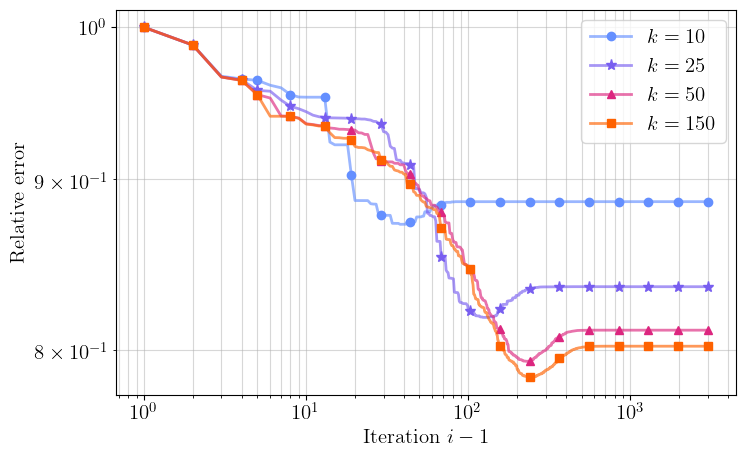

In [75]:
names3 = [f'$k = {k}$' for k in k_list]

plot_errors(result3['errors'], names=names3)

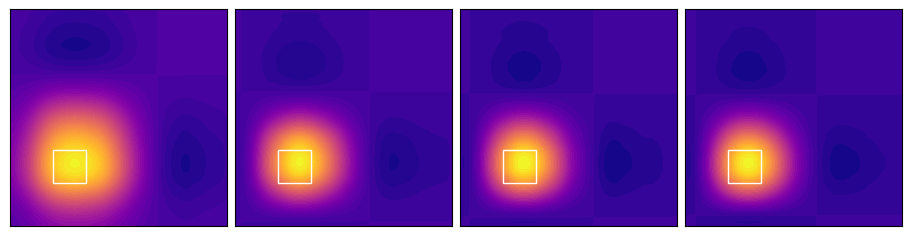

In [26]:
plot_multiple_f(result3['solutions'], pid='I')

In [ ]:
param_grid = [
    {'max_rank': 1, 'rtol': 0, 'max_iter': 1000, 'preconditioner': 'none'},
    {'max_rank': 1, 'rtol': 0, 'max_iter': 1000, 'preconditioner': 'jacobi'},
    {'max_rank': 1, 'rtol': 0, 'max_iter': 100, 'preconditioner': 'ic'},
    {'max_rank': 1, 'rtol': 0, 'max_iter': 10, 'preconditioner': 'cholesky'},
]

solutions2, errors, residuals = [], [], []
solver = DynamicalLowRankPCG(rsvd, pb['x'])

for params in param_grid:
    x = solver.solve(pb['y'], w, lam, **params)
    solutions2.append(x)
    errors.append(solver.error.copy())
    residuals.append(solver.residual.copy())


In [ ]:
plot_errors(residuals, names=['None', 'Jacobi', 'IC', 'Cholesky'], n_marks=30, fig_name='precondition_iterations')

In [ ]:
plot_multiple_f([as_func(x, pb['V_h']) for x in solutions2])

In [ ]:
precond = 'jacobi'
max_iter = 50_000
Nr_list = [2, 5, 25, 100, 200]
param_grid = [
    {'max_rank': 1, 'rtol': 0, 'max_iter': max_iter, 'preconditioner': precond},
    {'max_rank': 1, 'rtol': 0, 'max_iter': max_iter, 'preconditioner': precond},
    {'max_rank': 1, 'rtol': 0, 'max_iter': max_iter, 'preconditioner': precond},
    {'max_rank': 1, 'rtol': 0, 'max_iter': max_iter, 'preconditioner': precond},
    {'max_rank': 1, 'rtol': 0, 'max_iter': max_iter, 'preconditioner': precond},
]

solutions3, errors3, residuals3 = [], [], []
solver = DynamicalLowRankPCG(rsvd, pb['x'])

for Nr, params in zip(Nr_list, param_grid):
    x = solver.solve(pb['y'], w, lam, **params, restart_every=Nr, seed=SEED)
    solutions3.append(x)
    errors3.append(solver.error.copy())



In [ ]:
plot_errors(errors3, names=[f'$N_r={Nr}$' for Nr in Nr_list], n_marks=30, ylim=(0.7, 1.01))

In [ ]:
plot_multiple_f([as_func(x, pb['V_h']) for x in solutions3])
